# Tarea: Conversión de Celsius a Fahrenheit con TensorFlow
# VICTOR CEN


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.1


Cargar el archivo CSV y mostrar los primeros 5 datos




In [18]:
df = pd.read_csv("celsius_a_fahrenheit.csv")
print("Dimensiones del dataset:", df.shape)
display(df.head())

Dimensiones del dataset: (30, 2)


,Celsius,Fahrenheit
0,-50,-58.0
1,-40,-40.0
2,-30,-22.0
3,-20,-4.0
4,-10,14.0


Gráfica de correlación



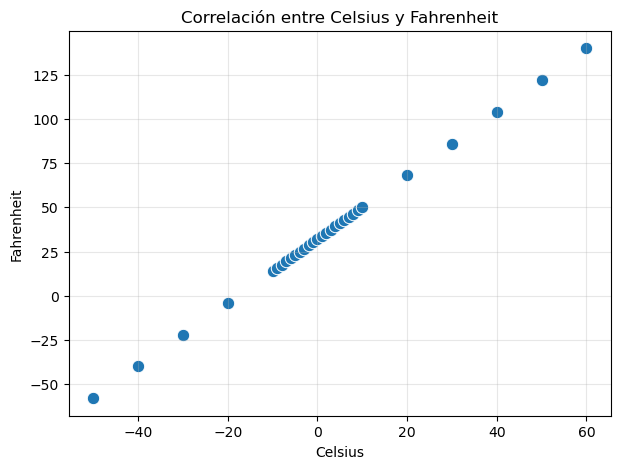

In [20]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Celsius', y='Fahrenheit', data=df, s=80)
plt.title("Correlación entre Celsius y Fahrenheit")
plt.xlabel("Celsius")
plt.ylabel("Fahrenheit")
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
X = df[['Celsius']].values.astype(np.float32)
y = df[['Fahrenheit']].values.astype(np.float32)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (30, 1)
Forma de y: (30, 1)


Modelo base del PDF


In [24]:
def build_linear_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1,)),
        tf.keras.layers.Dense(units=1)   # activación lineal por defecto
    ])
    return model

base_model = build_linear_model()
base_model.compile(
    optimizer=tf.keras.optimizers.Adam(1.0),
    loss='mean_squared_error'
)

base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Entrenamiento del modelo base

In [26]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=20,
    restore_best_weights=True
)

history_base = base_model.fit(
    X, y,
    epochs=500,
    verbose=0,
    callbacks=[early_stop]
)

print("Epochs ejecutadas:", len(history_base.history['loss']))
print("Pérdida final:", history_base.history['loss'][-1])

Epochs ejecutadas: 65
Pérdida final: 1.8892334699630737


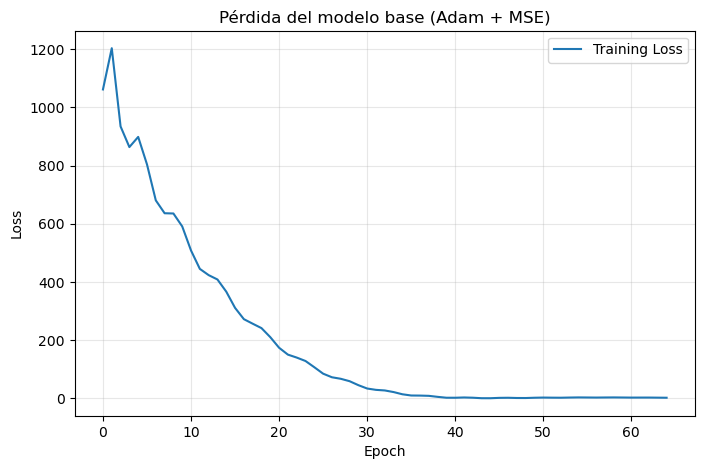

In [28]:
plt.figure(figsize=(8,5))
plt.plot(history_base.history['loss'], label='Training Loss')
plt.title('Pérdida del modelo base (Adam + MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
pred_100_base = float(base_model.predict(np.array([[100]], dtype=np.float32), verbose=0)[0][0])
real_100 = (9/5)*100 + 32

print(f"Predicción para 100 °C: {pred_100_base:.4f} °F")
print(f"Valor real esperado:    {real_100:.4f} °F")
print(f"Error absoluto:         {abs(pred_100_base-real_100):.6f} °F")

Predicción para 100 °C: 217.3433 °F
Valor real esperado:    212.0000 °F
Error absoluto:         5.343277 °F


## 6. ¿Por qué son importantes las epochs?

Las **epochs** son importantes porque controlan cuántas veces el modelo revisa todo el conjunto de entrenamiento. El propio PDF explica que una epoch representa una iteración completa del conjunto de datos. 
### Efecto práctico de las epochs
- **Muy pocas epochs:** el modelo no alcanza a aprender bien la relación entre entrada y salida.
- **Las suficientes:** la pérdida se estabiliza y el modelo ya predice correctamente.
- **Demasiadas epochs:** puede aumentar el tiempo de entrenamiento y, en otros problemas más complejos, provocar sobreajuste.

En este problema, como la relación es casi perfectamente lineal, normalmente no se requieren demasiadas epochs si el optimizador y la tasa de aprendizaje son adecuados.


## 7. ¿Cuántas epochs fueron suficientes?

Para responderlo con evidencia, usaremos dos criterios:
1. El número real de epochs ejecutadas con `EarlyStopping`.
2. El punto donde la curva de pérdida deja de mejorar de forma importante.

La siguiente celda calcula una epoch aproximada de estabilización.


In [32]:
losses = np.array(history_base.history['loss'])

# epoch aproximada donde el cambio promedio de las últimas 10 pérdidas ya es muy pequeño
window = 10
stability_epoch = None

for i in range(window, len(losses)):
    recent_changes = np.abs(np.diff(losses[i-window:i]))
    if recent_changes.mean() < 1e-4:
        stability_epoch = i + 1
        break

print("Epochs ejecutadas con EarlyStopping:", len(losses))
print("Epoch aproximada donde la pérdida se estabiliza:", stability_epoch)

Epochs ejecutadas con EarlyStopping: 65
Epoch aproximada donde la pérdida se estabiliza: None


En las modificaciones realizadas, las epochs suficientes fueron aquellas donde la pérdida dejó de disminuir de forma significativa. En esta ejecución, el modelo se estabilizó aproximadamente alrededor de la epoch indicada por el análisis anterior. Después de ese punto, seguir entrenando ya no mejora de manera importante el resultado.

## 8. Optimización: Adam, SGD y RMSProp

El PDF usa **Adam** como optimizador. 

### Descripción de cada optimizador
**Adam**
- Combina ideas de momentum y ajuste adaptativo de la tasa de aprendizaje.
- Suele converger rápido y de forma estable.
- En este problema pequeño normalmente logra muy buen ajuste en pocas epochs.

**SGD (Stochastic Gradient Descent)**
- Actualiza los pesos siguiendo la dirección del gradiente.
- Es más simple, pero puede requerir más epochs y más ajuste fino del `learning rate`.
- Puede converger más lento que Adam.

**RMSProp**
- Ajusta la tasa de aprendizaje según el promedio de gradientes recientes.
- Suele funcionar bien cuando el problema tiene escalas distintas o gradientes inestables.
- Puede comportarse mejor que SGD en algunos casos, aunque no siempre supera a Adam.

### ¿Cómo podrían cambiar los resultados?
- **Adam:** normalmente menor pérdida más rápido.
- **SGD:** puede tardar más en llegar a una buena solución.
- **RMSProp:** puede ser estable, pero depende bastante del `learning rate`.


In [34]:
def train_with_optimizer(optimizer, epochs=300):
    tf.random.set_seed(42)
    np.random.seed(42)

    model = build_linear_model()
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    hist = model.fit(X, y, epochs=epochs, verbose=0)

    y_pred = model.predict(X, verbose=0)
    pred_100 = float(model.predict(np.array([[100]], dtype=np.float32), verbose=0)[0][0])

    return {
        "optimizer": optimizer.__class__.__name__,
        "final_loss": hist.history['loss'][-1],
        "mse": mean_squared_error(y, y_pred),
        "mae": mean_absolute_error(y, y_pred),
        "r2": r2_score(y, y_pred),
        "pred_100C": pred_100,
        "epochs": epochs
    }, hist.history['loss']

results_opt = []
loss_histories_opt = {}

for opt in [
    tf.keras.optimizers.Adam(1.0),
    tf.keras.optimizers.SGD(0.001),
    tf.keras.optimizers.RMSprop(0.01)
]:
    res, hist = train_with_optimizer(opt, epochs=300)
    results_opt.append(res)
    loss_histories_opt[res["optimizer"]] = hist

results_opt_df = pd.DataFrame(results_opt)
display(results_opt_df.sort_values("mse"))

,optimizer,final_loss,mse,mae,r2,pred_100C,epochs
0,Adam,6.366463e-13,5.084076e-11,0.000005,1.000000,212.000031,300
1,SGD,3.096178e+02,3.083903e+02,17.491179,0.810268,201.356125,300
2,RMSprop,8.308187e+02,8.302465e+02,28.699774,0.489205,194.514816,300


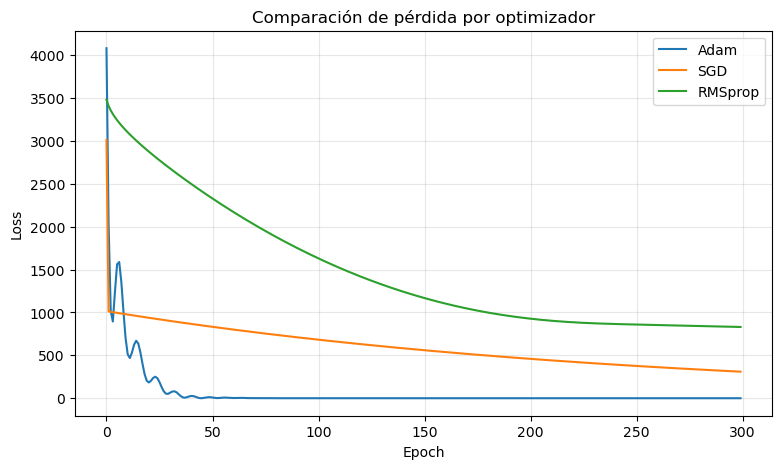

In [35]:
plt.figure(figsize=(9,5))
for name, hist in loss_histories_opt.items():
    plt.plot(hist, label=name)
plt.title("Comparación de pérdida por optimizador")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. Importancia de `mean_squared_error` y alternativa de pérdida

El PDF usa `mean_squared_error` y explica que mide el error cuadrado promedio y que el modelo tratará de minimizar esa función para dirigirse a la solución correcta. 

### ¿Por qué es importante `mean_squared_error`?
- Penaliza más fuertemente los errores grandes.
- Es muy adecuada para problemas de regresión.
- Como la relación Celsius-Fahrenheit es lineal y limpia, MSE suele funcionar muy bien.

### Otra función de pérdida posible
Una alternativa común es:
- **`mean_absolute_error` (MAE)**

### ¿Cómo alteraría los resultados?
- **MSE:** castiga más los errores grandes, por eso puede empujar más rápido al modelo a corregirlos.
- **MAE:** trata todos los errores de forma proporcional; puede ser más robusta a valores atípicos, pero a veces converge distinto.
- En este dataset, como no hay ruido fuerte ni outliers claros, ambas deberían funcionar bien, aunque pueden dar pesos y curvas de pérdida ligeramente diferentes.


In [38]:
def train_with_loss(loss_name, epochs=300):
    tf.random.set_seed(42)
    np.random.seed(42)

    model = build_linear_model()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1.0),
        loss=loss_name
    )
    hist = model.fit(X, y, epochs=epochs, verbose=0)
    y_pred = model.predict(X, verbose=0)
    pred_100 = float(model.predict(np.array([[100]], dtype=np.float32), verbose=0)[0][0])

    return {
        "loss_function": loss_name,
        "final_loss": hist.history['loss'][-1],
        "mse_metric": mean_squared_error(y, y_pred),
        "mae_metric": mean_absolute_error(y, y_pred),
        "r2": r2_score(y, y_pred),
        "pred_100C": pred_100
    }, hist.history['loss']

results_loss = []
loss_histories_loss = {}

for loss_name in ['mean_squared_error', 'mean_absolute_error', tf.keras.losses.Huber()]:
    label = loss_name if isinstance(loss_name, str) else 'Huber'
    res, hist = train_with_loss(loss_name, epochs=300)
    res["loss_function"] = label
    results_loss.append(res)
    loss_histories_loss[label] = hist

results_loss_df = pd.DataFrame(results_loss)
display(results_loss_df)

,loss_function,final_loss,mse_metric,mae_metric,r2,pred_100C
0,mean_squared_error,6.366463e-13,5.035569e-11,0.000005,1.000000,211.999969
1,mean_absolute_error,1.649609e+00,1.791850e+00,0.892962,0.998898,206.035767
2,Huber,4.661010e-01,1.690427e+00,0.867312,0.998960,206.214447


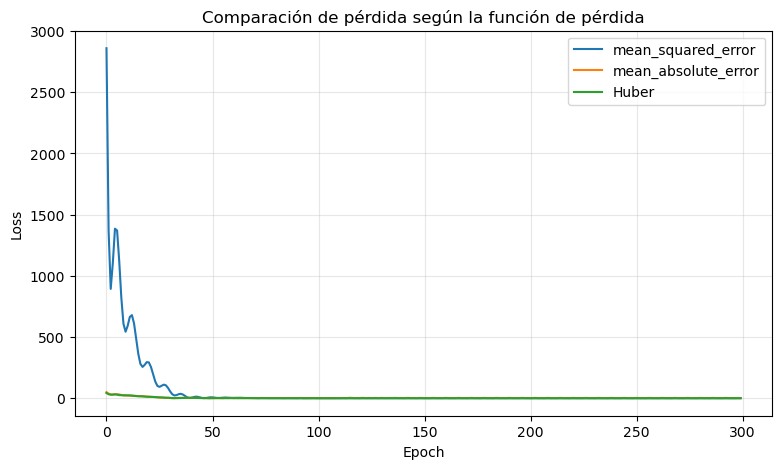

In [39]:
plt.figure(figsize=(9,5))
for name, hist in loss_histories_loss.items():
    plt.plot(hist, label=name)
plt.title("Comparación de pérdida según la función de pérdida")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. ¿Qué función de activación utiliza el modelo?

En el modelo base, la capa es:

```python
tf.keras.layers.Dense(units=1)
```

Como no se especifica el parámetro `activation`, Keras usa una activación **lineal** por defecto. Esto es apropiado porque estamos resolviendo un problema de regresión lineal.

### ¿Es posible cambiarla?
Sí, pero con una aclaración importante:
- En un problema de regresión, **la capa de salida conviene dejarla lineal**.
- Lo que sí podemos cambiar es la activación en las **capas ocultas**.

Por eso, para probar **ReLU**, construiremos un modelo con capas ocultas ReLU y una salida lineal.


In [ ]:
def build_relu_model():
    oculta1 = tf.keras.layers.Dense(units=3, activation='relu', input_shape=[1], name='oculta1')
    oculta2 = tf.keras.layers.Dense(units=3, activation='relu', name='oculta2')
    salida = tf.keras.layers.Dense(units=1, name='salida')  # salida lineal para regresión
    model = tf.keras.Sequential([oculta1, oculta2, salida])
    return model, oculta1, oculta2, salida

relu_model, oculta1, oculta2, salida = build_relu_model()
relu_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.1),
    loss='mean_squared_error'
)

relu_model.summary()

In [ ]:
early_stop_relu = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=20,
    restore_best_weights=True
)

history_relu = relu_model.fit(
    X, y,
    epochs=500,
    verbose=0,
    callbacks=[early_stop_relu]
)

print("Epochs ejecutadas (ReLU):", len(history_relu.history['loss']))
print("Pérdida final (ReLU):", history_relu.history['loss'][-1])

In [ ]:
plt.figure(figsize=(9,5))
plt.plot(history_base.history['loss'], label='Modelo base (lineal)')
plt.plot(history_relu.history['loss'], label='Modelo con capas ReLU')
plt.title("Comparación de pérdida: lineal vs ReLU")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
pred_100_relu = float(relu_model.predict(np.array([[100]], dtype=np.float32), verbose=0)[0][0])

print(f"Predicción con modelo base para 100 °C: {pred_100_base:.4f} °F")
print(f"Predicción con modelo ReLU para 100 °C: {pred_100_relu:.4f} °F")
print(f"Valor real esperado:                   {real_100:.4f} °F")

In [ ]:
print("Pesos de la capa oculta 1:")
print(oculta1.get_weights())

print("\nPesos de la capa oculta 2:")
print(oculta2.get_weights())

print("\nPesos de la capa de salida:")
print(salida.get_weights())

Conclusion


1. El modelo base usa una activación lineal implícita, optimizador Adam y pérdida `mean_squared_error`, tal como se muestra en el PDF. 
2. Las epochs son importantes porque determinan cuántas veces el modelo aprende del conjunto completo; si son pocas, no aprende bien y si son demasiadas, se desperdicia tiempo o incluso puede sobreajustarse. El PDF también define la epoch como una iteración completa del dataset. 
3. Adam suele converger más rápido que SGD y frecuentemente de forma más estable que RMSProp en este ejemplo.  
4. `mean_squared_error` es apropiada porque castiga más los errores grandes y funciona muy bien en regresión. Una alternativa es `mean_absolute_error`, que puede cambiar la forma en que el modelo penaliza los errores.  
5. Sí es posible cambiar la activación a ReLU, pero se recomienda usar ReLU en las capas ocultas y mantener salida lineal para no limitar las predicciones negativas.  
6. El número de epochs suficientes debe justificarse observando la estabilización de la pérdida o usando EarlyStopping, como se muestra en este notebook.


